# 🏆 Nairobi OS vs Pandas: NBA Dataset Benchmarks
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KevinKenya/nairobi-connector-open-source/blob/main/nairobi-benchmarks/nairobiOsBenchmarks.ipynb)

This notebook benchmarks **Nairobi OS** (fused analytics engine) against **Pandas** using the real NBA Player Statistics dataset. All comparisons use identical operations for a fair head-to-head test.

**Workloads tested:**
- Statistical Distillation (mean, std_dev, skewness, kurtosis)
- Pearson Correlation between key player stats
- End-to-end pipeline (ingest + crunch + correlate)


In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
eoinamoore_historical_nba_data_and_player_box_scores_path = kagglehub.dataset_download('eoinamoore/historical-nba-data-and-player-box-scores')

print('Data source import complete.')

Using Colab cache for faster access to the 'historical-nba-data-and-player-box-scores' dataset.
Data source import complete.


## 🔧 Setup: Load the NBA Dataset & Start Engines

In [2]:
!pip install nairobi_os -v

Using pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
  Obtaining dependency information for nairobi_os from https://files.pythonhosted.org/packages/ec/f3/dab37af042e14fd16fe17ef243df38781c6d586242a0edf7887a10e1da67/nairobi_os-0.3.0-cp312-cp312-manylinux_2_34_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 65.2 MB/s eta 0:00:00


In [3]:
import os
import subprocess
import stat
from pathlib import Path
import nairobi_os
import pandas as pd
import gc

# Use the path from kagglehub if available, otherwise look in standard Kaggle mount points
try:
    nba_input_dir = eoinamoore_historical_nba_data_and_player_box_scores_path
except NameError:
    # Fallback to common Kaggle mount paths
    possible_paths = [
        "/kaggle/input/historical-nba-data-and-player-box-scores",
        "/kaggle/input/eoinamoore/historical-nba-data-and-player-box-scores"
    ]
    nba_input_dir = next((p for p in possible_paths if os.path.exists(p)), possible_paths[0])

csv_files = []
for dirname, _, filenames in os.walk(nba_input_dir):
    for f in filenames:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(dirname, f))

if not csv_files:
    raise ValueError(f"No CSV files found in {nba_input_dir}. Please check your Kaggle data sources.")

print(f"Found {len(csv_files)} CSV files in {nba_input_dir}:")
for f in csv_files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"  {f} ({size_mb:.1f} MB)")

# Use the largest CSV (player box scores) as our benchmark dataset
nba_dataset = max(csv_files, key=lambda f: os.path.getsize(f))
print(f"\n✅ Selected dataset: {nba_dataset}")

# Copy to working directory for consistent access
dataset_basename = os.path.basename(nba_dataset)
local_dataset = f"/kaggle/working/{dataset_basename}"
# Create working dir if it doesn't exist (for non-Kaggle envs)
os.makedirs("/kaggle/working", exist_ok=True)
!cp {nba_dataset} {local_dataset}

# Quick peek at the data
df_peek = pd.read_csv(local_dataset, low_memory=False)
print(f"\n📊 Dataset shape: {df_peek.shape}")
print(f"   Columns: {list(df_peek.columns[:15])}...")
print(f"   Sample rows:")
print(df_peek.head(3).to_string())

# Ensure memory is cleared
del df_peek
gc.collect()
print("\n🧹 Memory cleared: Inspection DataFrames dropped.")

Found 9 CSV files in /kaggle/input/historical-nba-data-and-player-box-scores:
  /kaggle/input/historical-nba-data-and-player-box-scores/Players.csv (0.5 MB)
  /kaggle/input/historical-nba-data-and-player-box-scores/PlayerStatisticsExtended.csv (432.1 MB)
  /kaggle/input/historical-nba-data-and-player-box-scores/TeamStatistics.csv (34.3 MB)
  /kaggle/input/historical-nba-data-and-player-box-scores/PlayerStatistics.csv (371.5 MB)
  /kaggle/input/historical-nba-data-and-player-box-scores/Games.csv (10.7 MB)
  /kaggle/input/historical-nba-data-and-player-box-scores/LeagueSchedule25_26.csv (0.2 MB)
  /kaggle/input/historical-nba-data-and-player-box-scores/TeamHistories.csv (0.0 MB)
  /kaggle/input/historical-nba-data-and-player-box-scores/TeamStatisticsExtended.csv (36.4 MB)
  /kaggle/input/historical-nba-data-and-player-box-scores/LeagueSchedule24_25.csv (0.1 MB)

✅ Selected dataset: /kaggle/input/historical-nba-data-and-player-box-scores/PlayerStatisticsExtended.csv

📊 Dataset shape: (838

In [4]:
# Start the Nairobi OS Axum Refinery daemon
import subprocess
from pathlib import Path

print("🛠 Installing D-Bus Infrastructure...")
subprocess.run(["apt-get", "update", "-qq"], capture_output=True)
subprocess.run(["apt-get", "install", "-y", "-qq", "dbus-x11"], capture_output=True)

print("🔌 Initializing D-Bus Session...")
dbus_out = subprocess.check_output(["dbus-launch"]).decode()
for line in dbus_out.splitlines():
    if "=" in line:
        k, v = line.split("=", 1)
        os.environ[k] = v.replace(";", "").replace("'", "").replace('"', '')

print("🔐 Granting Executable Permissions...")
bin_path = Path(nairobi_os.__file__).parent / "bin" / "nairobi-axum-refinery"
os.chmod(bin_path, 0o755)

print("🔥 Igniting the Heavy Iron (Nairobi OS)...")
try:
    nairobi_os.start_refinery()
    print("✅ AXUM REFINERY ONLINE")
except Exception as e:
    print(f"\n💥 Ignition Failed: {e}")
    os.system("cat ~/.nairobi_refinery.log 2>/dev/null || echo 'No log file'")

🛠 Installing D-Bus Infrastructure...
🔌 Initializing D-Bus Session...
🔐 Granting Executable Permissions...
🔥 Igniting the Heavy Iron (Nairobi OS)...
✅ AXUM REFINERY ONLINE


## 📊 Benchmark 1: Statistical Distillation (3 Iterations)

Compute **mean, std_dev, skewness, kurtosis** on the `points` column — the core statistical primitives. **Timeout:60seconds**

In [5]:
import time
import json
import numpy as np
import pandas as pd
import nairobi_os
import gc
import os

NUM_ITERATIONS = 3
TIMEOUT_SEC = 60
column = "points"

# ── PANDA BENCHMARK ──────────────────────────────
print("  Pandas Statistical Distillation...")
pandas_ingest_times = []
pandas_crunch_times = []
pandas_totals = []
pandas_results = None

pandas_start_wall = time.perf_counter()
for i in range(NUM_ITERATIONS):
    if time.perf_counter() - pandas_start_wall > TIMEOUT_SEC: break
    t0 = time.perf_counter_ns()
    df_p = pd.read_csv(local_dataset, low_memory=False)
    ingest_ms = (time.perf_counter_ns() - t0) / 1_000_000
    pandas_ingest_times.append(ingest_ms)

    t1 = time.perf_counter_ns()
    mean_val, std_val = df_p[column].mean(), df_p[column].std()
    skew_val, kurt_val = df_p[column].skew(), df_p[column].kurt()
    crunch_ms = (time.perf_counter_ns() - t1) / 1_000_000
    pandas_crunch_times.append(crunch_ms)
    pandas_totals.append(ingest_ms + crunch_ms)
    if pandas_results is None: pandas_results = {"mean": mean_val, "std_dev": std_val, "skewness": skew_val, "kurtosis": kurt_val}
    del df_p
    gc.collect()

print(f"  Mean Latency (Total): {np.mean(pandas_totals):.2f} ms")

# ── NAIROBI BENCHMARK ───────────────────────────
print("\n★ Nairobi OS Statistical Distillation...")
nairobi_ingest_times, nairobi_crunch_times, nairobi_totals = [], [], []
nairobi_results = None

nairobi_start_wall = time.perf_counter()
for i in range(NUM_ITERATIONS):
    if time.perf_counter() - nairobi_start_wall > TIMEOUT_SEC: break
    t0 = time.perf_counter_ns()
    data_ref = nairobi_os.data.ingest(local_dataset)
    ingest_ms = (time.perf_counter_ns() - t0) / 1_000_000
    nairobi_ingest_times.append(ingest_ms)

    t1 = time.perf_counter_ns()
    # Call crunch as a module function passing the reference
    stats_json = nairobi_os.data.crunch(data_ref, column)
    stats = json.loads(stats_json) if isinstance(stats_json, str) else stats_json
    crunch_ms = (time.perf_counter_ns() - t1) / 1_000_000
    nairobi_crunch_times.append(crunch_ms)
    nairobi_totals.append(ingest_ms + crunch_ms)

    if nairobi_results is None: nairobi_results = stats
    nairobi_os.data.free(data_ref)
    gc.collect()

print(f"  Mean Latency (Total): {np.mean(nairobi_totals):.2f} ms")

  Pandas Statistical Distillation...
  Mean Latency (Total): 21281.50 ms

★ Nairobi OS Statistical Distillation...
  Mean Latency (Total): 6569.90 ms


## 📊 Benchmark 2: Pearson Correlation (3 Iterations)

Compute Pearson correlation between **points** and **assists** — a pairwise statistical operation.

In [6]:
import gc
import time
import numpy as np
import pandas as pd
import json
import nairobi_os

NUM_ITERATIONS = 3
TIMEOUT_SEC = 60

# ── PANDA BENCHMARK ──────────────────────────────
print("☐ Pandas Pearson Correlation...")
pandas_corr_times = []
pandas_corr_result = None

pandas_loop_start = time.perf_counter()
for i in range(NUM_ITERATIONS):
    if time.perf_counter() - pandas_loop_start > TIMEOUT_SEC: break
    t0 = time.perf_counter_ns()
    df_p = pd.read_csv(local_dataset, low_memory=False)
    corr_val = df_p["points"].corr(df_p["assists"], method="pearson")
    elapsed_ms = (time.perf_counter_ns() - t0) / 1_000_000
    pandas_corr_times.append(elapsed_ms)
    if pandas_corr_result is None: pandas_corr_result = corr_val
    del df_p
    gc.collect()

# ── NAIROBI BENCHMARK ───────────────────────────
print("\n★ Nairobi OS Pearson Correlation...")
nairobi_corr_times = []
nairobi_corr_result = None

nairobi_loop_start = time.perf_counter()
for i in range(NUM_ITERATIONS):
    if time.perf_counter() - nairobi_loop_start > TIMEOUT_SEC: break
    t0 = time.perf_counter_ns()
    data_ref = nairobi_os.data.ingest(local_dataset)
    # Call correlate as a module function passing the reference
    corr_json = nairobi_os.data.correlate(data_ref, "points,assists")
    corr_res = json.loads(corr_json) if isinstance(corr_json, str) else corr_json
    elapsed_ms = (time.perf_counter_ns() - t0) / 1_000_000
    nairobi_corr_times.append(elapsed_ms)
    if nairobi_corr_result is None: nairobi_corr_result = corr_res["pearson"]
    nairobi_os.data.free(data_ref)
    gc.collect()

print(f"  Mean Latency: {np.mean(nairobi_corr_times):.2f} ms")

☐ Pandas Pearson Correlation...

★ Nairobi OS Pearson Correlation...
  Mean Latency: 5627.21 ms


## 📊 Benchmark 3: Fused Pipeline (Ingest + Crunch + Correlate) 3 iterations
End-to-end fused analytics: ingest, compute statistics, and correlate in a single call via `nairobi_os.data.pipeline()`.

In [7]:
import gc
import time
import numpy as np
import pandas as pd
import json
import nairobi_os

NUM_ITERATIONS = 3
TIMEOUT_SEC = 60

# ── FUSED PIPELINE BENCHMARK ─────────────────────
print("🦁 Nairobi OS Fused Pipeline (Ingest + Crunch + Correlate)...")
pipeline_times = []
pipeline_result = None

nairobi_loop_start = time.perf_counter()
for i in range(NUM_ITERATIONS):
    if time.perf_counter() - nairobi_loop_start > TIMEOUT_SEC:
        print(f"  ☐ Nairobi timeout reached after {i} iterations")
        break
    t0 = time.perf_counter_ns()
    result_json = nairobi_os.data.pipeline(
        local_dataset,
        "points",
        "assists,reboundsTotal"
    )
    elapsed_ms = (time.perf_counter_ns() - t0) / 1_000_000
    pipeline_times.append(elapsed_ms)
    if pipeline_result is None:
        pipeline_result = json.loads(result_json)
    gc.collect()

print(f"  Mean total time: {np.mean(pipeline_times):.2f} ms")

# ── COMPARISON: Pandas equivalent (3 separate ops) ──
print("\n🐼 Pandas Equivalent (Read + Stats + Correlate)...")
pandas_pipeline_times = []

pandas_loop_start = time.perf_counter()
for i in range(NUM_ITERATIONS):
    if time.perf_counter() - pandas_loop_start > TIMEOUT_SEC:
        print(f"  ☐ Pandas timeout reached after {i} iterations")
        break
    t0 = time.perf_counter_ns()
    df_p = pd.read_csv(local_dataset, low_memory=False)
    _ = df_p["points"].mean()
    _ = df_p["points"].std()
    _ = df_p["assists"].corr(df_p["reboundsTotal"], method="pearson")
    elapsed_ms = (time.perf_counter_ns() - t0) / 1_000_000
    pandas_pipeline_times.append(elapsed_ms)

    del df_p
    gc.collect()

print(f"  Mean total time: {np.mean(pandas_pipeline_times):.2f} ms")

# ── SUMMARY ──────────────────────────────────────
print("\n" + "="*60)
print("BENCHMARK SUMMARY: Fused Pipeline vs Pandas")
print("="*60)
pipeline_speedup = np.mean(pandas_pipeline_times) / np.mean(pipeline_times)
print(f"{'Metric':<30} {'Pandas (ms)':<15} {'Nairobi (ms)':<15} {'Speedup':<10}")
print("-" * 60)
print(f"{'Full Pipeline':<30} {np.mean(pandas_pipeline_times):<15.2f} {np.mean(pipeline_times):<15.2f} {pipeline_speedup:.2f}x")
print("="*60)

gc.collect()

🦁 Nairobi OS Fused Pipeline (Ingest + Crunch + Correlate)...
  Mean total time: 5251.58 ms

🐼 Pandas Equivalent (Read + Stats + Correlate)...
  Mean total time: 20055.23 ms

BENCHMARK SUMMARY: Fused Pipeline vs Pandas
Metric                         Pandas (ms)     Nairobi (ms)    Speedup   
------------------------------------------------------------
Full Pipeline                  20055.23        5251.58         3.82x


0

## 📈 Results Summary

Run all three benchmarks above and compare the results table below.

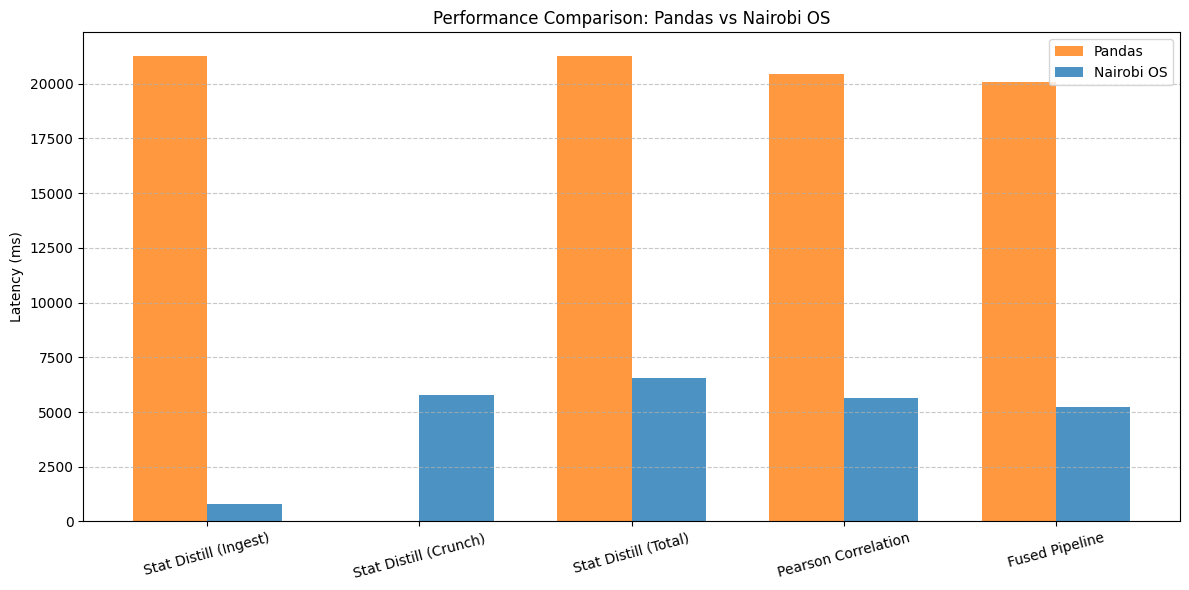

Benchmark,Pandas (ms),Nairobi (ms),Speedup
Stat Distill (Ingest),21252.78,791.02,26.87x
Stat Distill (Crunch),28.73,5778.88,0.00x
Stat Distill (Total),21281.50,6569.90,3.24x
Pearson Correlation,20442.37,5627.21,3.63x
Fused Pipeline,20055.23,5251.58,3.82x


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Collect results from all benchmarks
bench_names = [
    "Stat Distill (Ingest)",
    "Stat Distill (Crunch)",
    "Stat Distill (Total)",
    "Pearson Correlation",
    "Fused Pipeline"
]

pandas_means = [
    np.mean(pandas_ingest_times),
    np.mean(pandas_crunch_times),
    np.mean(pandas_totals),
    np.mean(pandas_corr_times),
    np.mean(pandas_pipeline_times)
]

nairobi_means = [
    np.mean(nairobi_ingest_times),
    np.mean(nairobi_crunch_times),
    np.mean(nairobi_totals),
    np.mean(nairobi_corr_times),
    np.mean(pipeline_times)
]

# Create DataFrame for display
df_results = pd.DataFrame({
    "Benchmark": bench_names,
    "Pandas (ms)": pandas_means,
    "Nairobi (ms)": nairobi_means
})
df_results["Speedup"] = df_results["Pandas (ms)"] / df_results["Nairobi (ms)"]

# --- Visual Comparison Plot ---
plt.figure(figsize=(12, 6))
x = np.arange(len(bench_names))
width = 0.35

plt.bar(x - width/2, pandas_means, width, label='Pandas', color='#ff7f0e', alpha=0.8)
plt.bar(x + width/2, nairobi_means, width, label='Nairobi OS', color='#1f77b4', alpha=0.8)

plt.ylabel('Latency (ms)')
plt.title('Performance Comparison: Pandas vs Nairobi OS')
plt.xticks(x, bench_names, rotation=15)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Formatted Table Output ---
from IPython.display import display, HTML
display(HTML('<h3>🏆 Nairobi OS vs Pandas — Benchmark Results</h3>'))

# Format for display
display_df = df_results.copy()
display_df["Pandas (ms)"] = display_df["Pandas (ms)"].apply(lambda x: f"{x:.2f}")
display_df["Nairobi (ms)"] = display_df["Nairobi (ms)"].apply(lambda x: f"{x:.2f}")
display_df["Speedup"] = display_df["Speedup"].apply(lambda x: f"{x:.2f}x")

display(HTML(display_df.to_html(index=False, table_id='bench-table')))

## 🔧 Teardown

Stop the Axum refinery daemon when done.

In [10]:
nairobi_os.stop_refinery()
print("🛑 Axum refinery stopped.")

🛑 Axum refinery stopped.
